In [58]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [59]:
ime = "usdjpy"

df = pd.read_csv(f"data/{ime}.csv")

print(df.columns)
print(df.head())

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%m/%d/%Y",
    errors="raise"
)

# Sort oldest -> newest
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.tail())

Index(['Date', 'Close'], dtype='str')
         Date   Close
0  10/30/1996  114.18
1  11/01/1996  113.50
2  11/04/1996  113.88
3  11/05/1996  114.25
4  11/06/1996  113.95
        Date   Close
0 1996-10-30  114.18
1 1996-11-01  113.50
2 1996-11-04  113.88
3 1996-11-05  114.25
4 1996-11-06  113.95
           Date    Close
9420 2026-08-03  157.529
9421 2026-08-04  157.692
9422 2026-08-05  157.600
9423 2026-08-06  158.409
9424 2026-08-07  157.806


In [60]:
features = ["Close"]

# Scale data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

In [61]:
LOOKBACK = 1095

X = []
y = []

for i in range(LOOKBACK, len(scaled)):
    X.append(scaled[i - LOOKBACK:i])
    y.append(scaled[i, 0])     # Close value

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8330, 1095, 1)
y shape: (8330,)


In [62]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, len(features))),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100


c:\Users\Aca\Desktop\Petnica\Mentorski rad\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 68s 394ms/step - loss: 0.0047 - mae: 0.0320 - val_loss: 9.2994e-05 - val_mae: 0.0070
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 61s 364ms/step - loss: 2.6261e-04 - mae: 0.0125 - val_loss: 1.0092e-04 - val_mae: 0.0076
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 62s 371ms/step - loss: 2.4776e-04 - mae: 0.0121 - val_loss: 8.6228e-05 - val_mae: 0.0067
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 64s 381ms/step - loss: 2.2898e-04 - mae: 0.0116 - val_loss: 9.4393e-05 - val_mae: 0.0072
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 64s 385ms/step - loss: 2.1949e-04 - mae: 0.0114 - val_loss: 1.1222e-04 - val_mae: 0.0084
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 64s 386ms/step - loss: 2.0533e-04 - mae: 0.0109 - val_loss: 8.1882e-05 - val_mae: 0.0069
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 65s 387ms/step - loss: 1.9128e-04 - mae: 0.0106 - val_loss: 1.2802e-04 - val_mae: 0.0090
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 65s 386ms/step - loss: 1.7870e-04 - mae: 0.0102 - val_loss: 1.068

In [ ]:
pred = model.predict(X_test)

# Convert predicted Close back to original scale
dummy = np.zeros((len(pred), 2))
dummy[:, 1] = pred[:, 0]

pred_close = scaler.inverse_transform(dummy)[:, 1]

print("Predicted close:")
print(pred_close[:10])


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Predicted close:
[109.40376786 109.55310213 109.37487461 109.57429419 109.5934487
 109.64866988 109.96037243 110.02381993 110.66144847 110.29097742]


In [ ]:
pred = model.predict(X_test)

# Convert predicted Close back to original scale
dummy = np.zeros((len(pred), 2))
dummy[:, 1] = pred[:, 0]

pred_close = scaler.inverse_transform(dummy)[:, 1]

# Convert measured Close back to original scale
dummy_y = np.zeros((len(y_test), 2))
dummy_y[:, 1] = y_test

measured_close = scaler.inverse_transform(dummy_y)[:, 1]

# Dates for test period
test_dates = df["Date"].iloc[LOOKBACK + split_idx:].reset_index(drop=True)

min_len = min(len(test_dates), len(measured_close), len(pred_close))

test_dates = test_dates.iloc[:min_len]
measured_close = measured_close[:min_len]
pred_close = pred_close[:min_len]

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


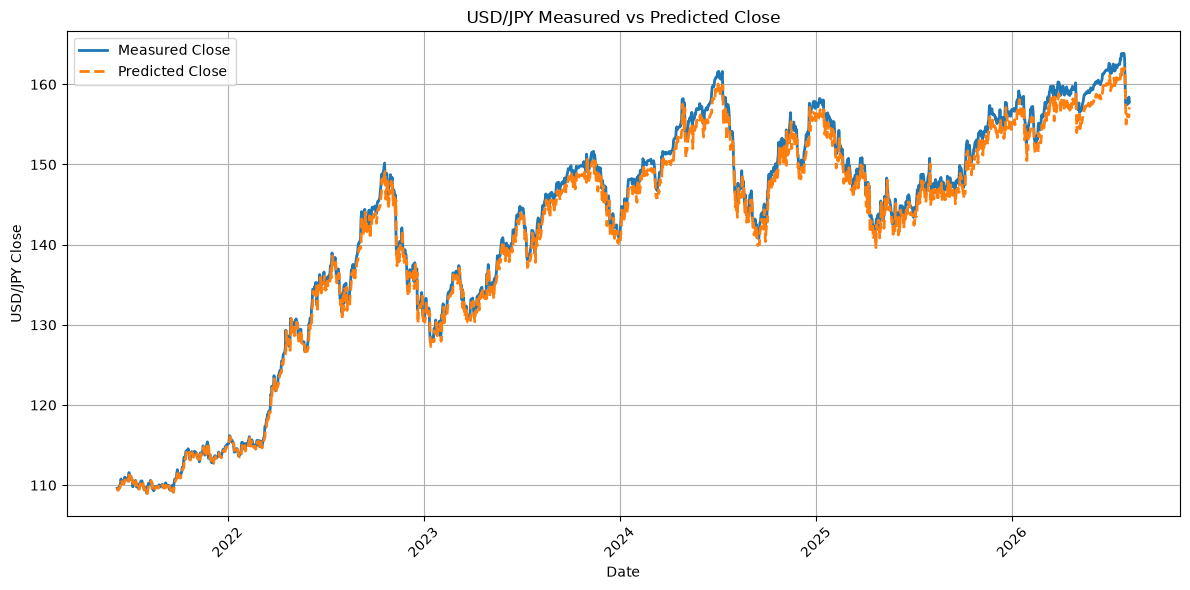

MAE: 1.0700815722239474
RMSE: 1.2970562739829643
R^2: 0.9924602262627579


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_dates, measured_close, label="Measured Close", linewidth=2)
plt.plot(test_dates, pred_close, label="Predicted Close", linewidth=2, linestyle="--")

plt.title(f"{ime.upper()[0:3]}/{ime.upper()[3:6]} Measured vs Predicted Close")
plt.xlabel("Date")
plt.ylabel(f"{ime.upper()[0:3]}/{ime.upper()[3:6]} Close")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mae = mean_absolute_error(measured_close, pred_close)
rmse = np.sqrt(mean_squared_error(measured_close, pred_close))
r2 = r2_score(measured_close, pred_close)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

In [ ]:
model.save(f"{ime}_lstm.keras")
joblib.dump(scaler, f"{ime}_scaler.pkl")
config = {
    "lookback": LOOKBACK,
    "features": features
}

joblib.dump(config, f"{ime}_config.pkl")

['usdjpy_config.pkl']

In [ ]:
from tensorflow.keras.models import load_model
import joblib

model = load_model(f"{ime}_{LOOKBACK}_lstm.keras")
scaler = joblib.load(f"{ime}_{LOOKBACK}_scaler.pkl")
config = joblib.load(f"{ime}_{LOOKBACK}_config.pkl")

LOOKBACK = config["lookback"]
features = config["features"]